# Late-Time Radio Light Curve of SN 2018ivc (Post-100 Days)

Zoom-in of the full radio light curve (`full_radio_lightcurve.ipynb`) restricted to phases > 100 days. Color encodes frequency (turbo colormap, canonical `LogNorm(vmin=1, vmax=250)` per `CLAUDE_plotting.md`). Vertical dashed lines mark the three rebrightening epochs, labeled to match the epoch averages used in `sed_epoch_grid.ipynb` (Epoch 1: 1327 days, Epoch 2: 2141 days, Epoch 3: 2494 days).

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
from scipy.interpolate import PchipInterpolator
import functions

functions.set_plot_style()

def darken_color(color, factor=0.7):
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

# --- Load data, restrict to the late-time (post-100 day) window ---
data = pd.read_csv("../data/radio_18ivc_data.csv")
data = data[data["phase"] > 100]

# --- Canonical epoch->viridis color mapping (CLAUDE_plotting.md / sed_epoch_grid.ipynb) ---
# Full 8-epoch project timeline, so these three late-time epochs get the same
# color here as their matching panels in sed_epoch_grid.ipynb.
canonical_epoch_labels = [4.0, 20.0, 200.0, 1300.0, 1700.0, 2100.0, 2500.0, 2650.0]
viridis = mpl.colormaps["viridis"]
canonical_epoch_colors = {
    label: viridis(x)
    for label, x in zip(canonical_epoch_labels, np.linspace(1, 0, len(canonical_epoch_labels)))
}

# Rebrightening epochs to flag with vertical dashed lines. Phases and labels
# match the epoch averages computed in sed_epoch_grid.ipynb for the same
# phase-range bins (1200-1400, 2000-2200, 2350-2550 days), and each is colored
# to match its corresponding panel there (1300.0, 2100.0, 2500.0 canonical epochs).
rebrightening_epochs = [
    (1326.9, "Epoch 1 (1327 days)", canonical_epoch_colors[1300.0]),
    (2140.6, "Epoch 2 (2141 days)", canonical_epoch_colors[2100.0]),
    (2494.5, "Epoch 3 (2494 days)", canonical_epoch_colors[2500.0]),
]

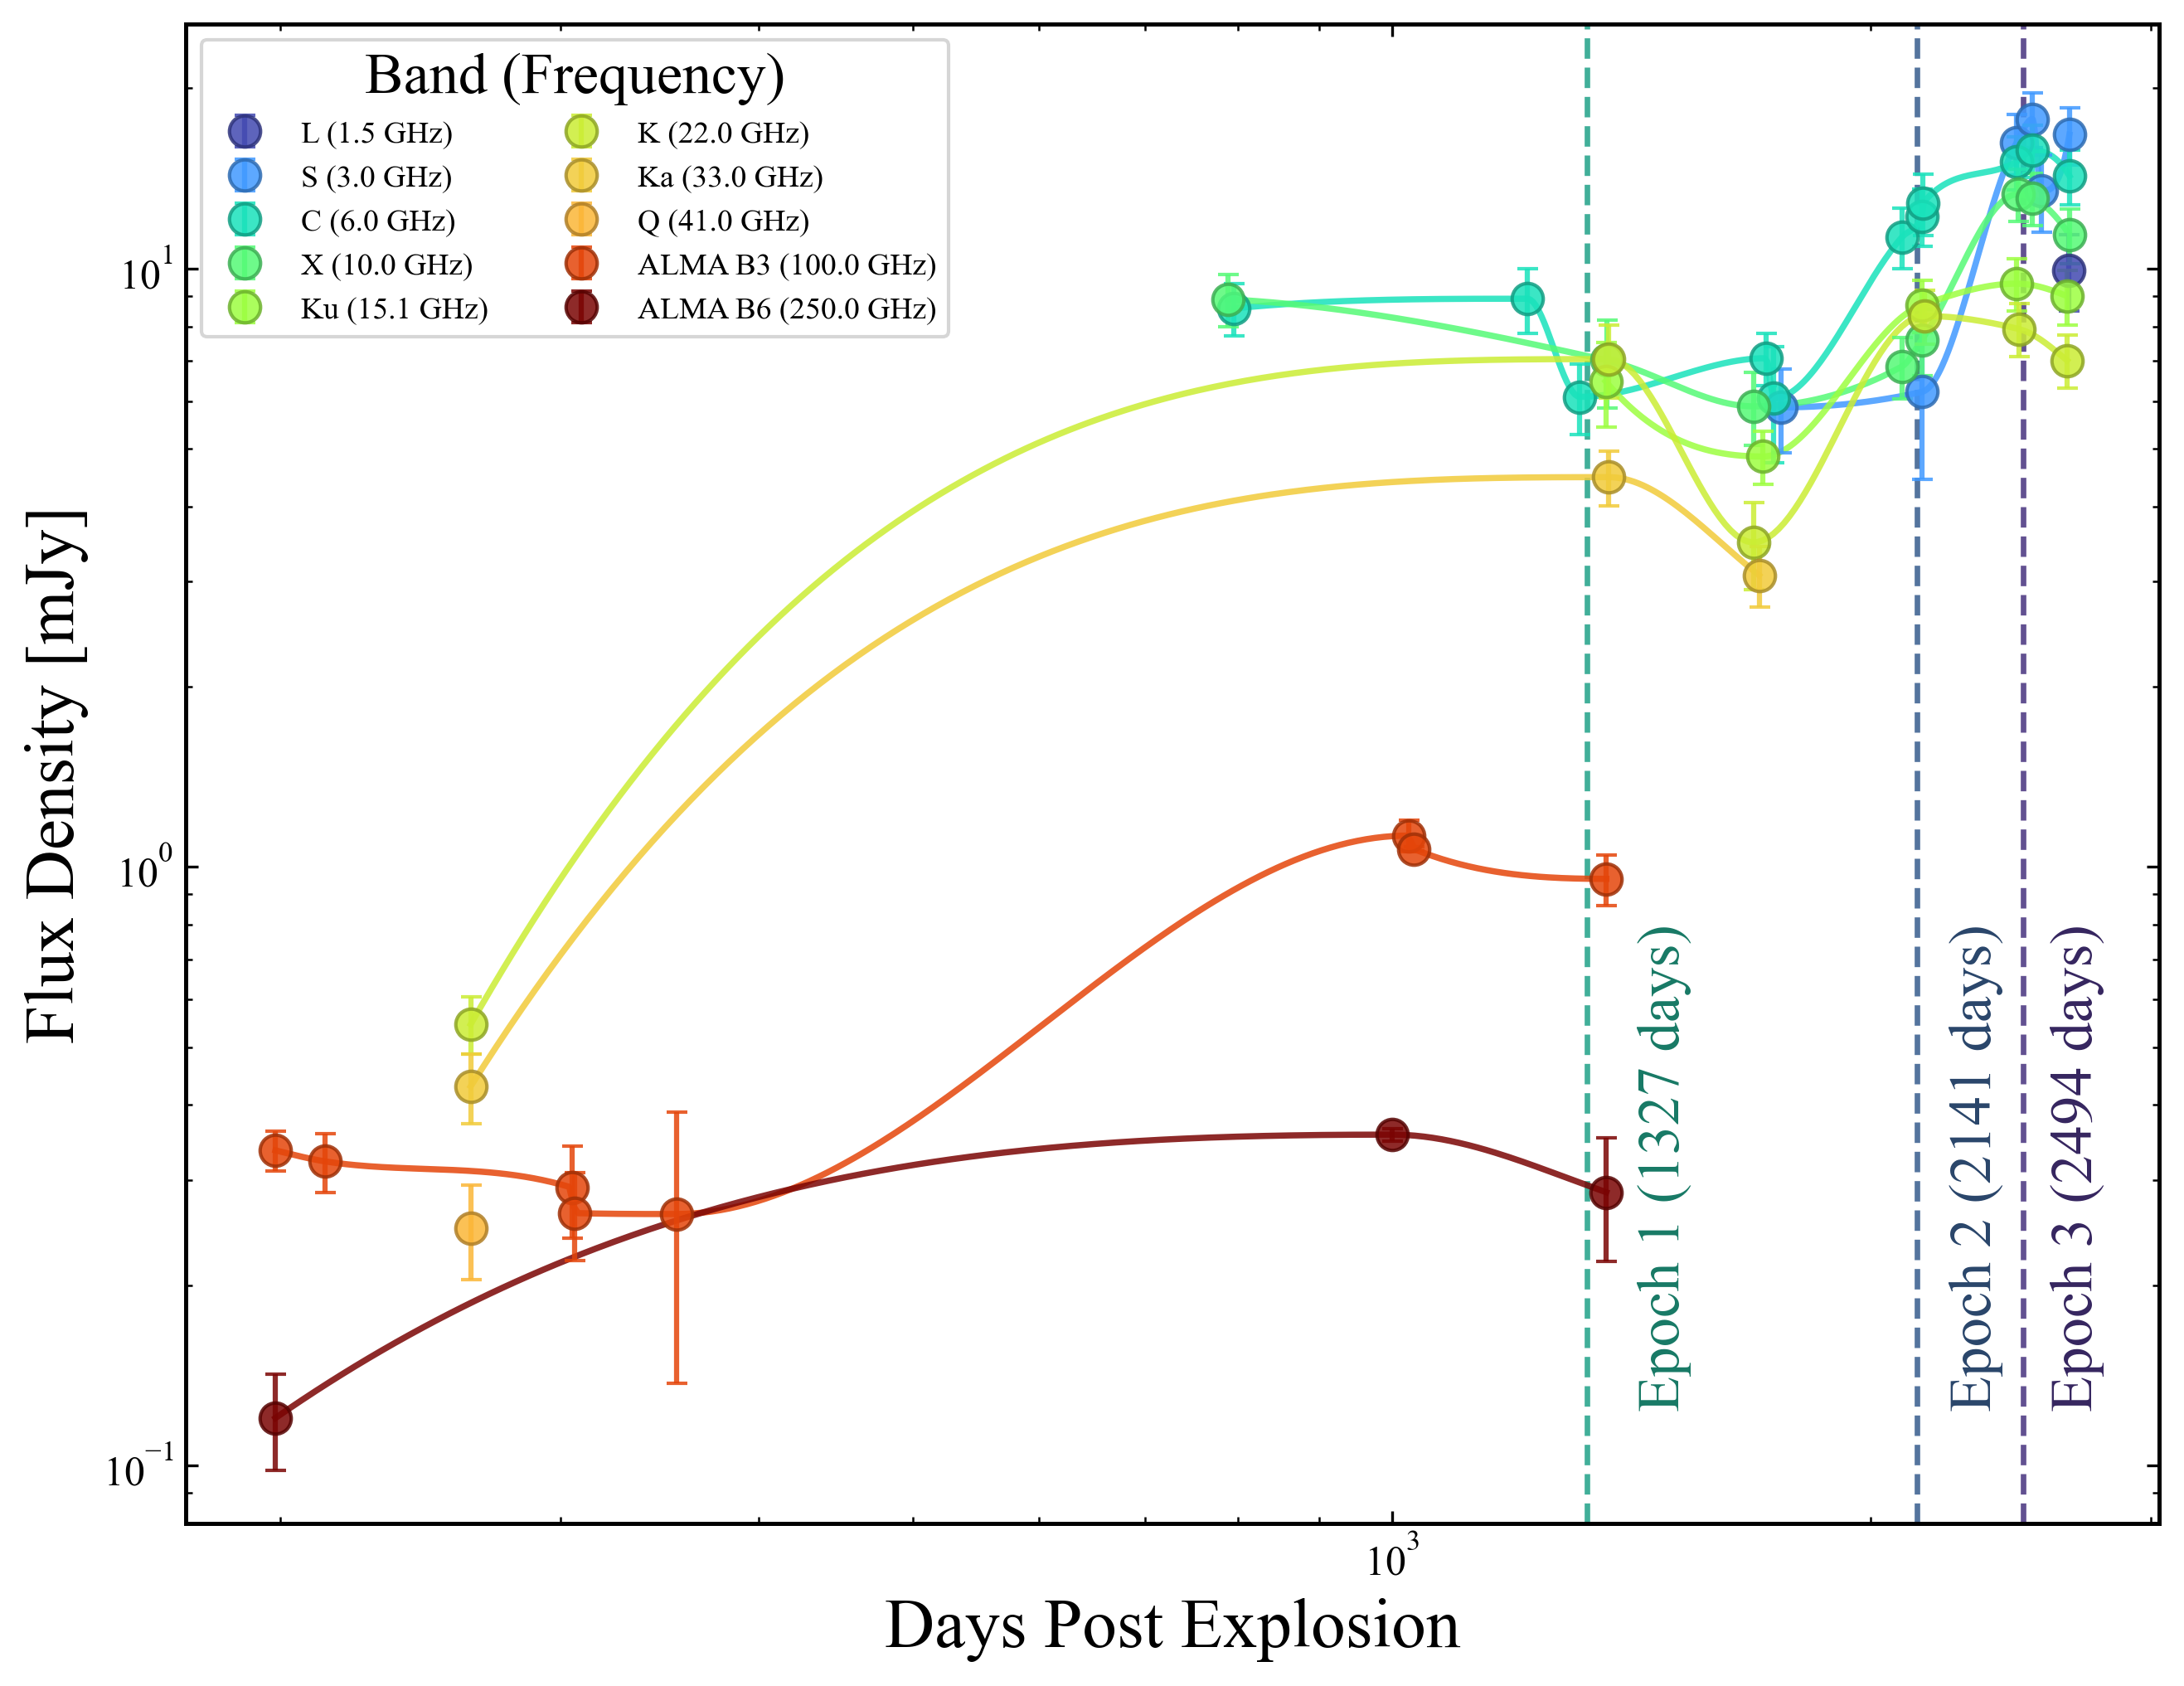

In [2]:
# Canonical turbo/frequency norm (CLAUDE_plotting.md): full 1-250 GHz dataset range
norm = LogNorm(vmin=1, vmax=250)
cmap = mpl.colormaps["turbo"]

# Band definitions spanning the full dataset: VLA L through Q, plus the two ALMA
# continuum windows the early/late mm-wave points fall in.
band_ranges = {
    "L":  (1.0, 2.0),
    "S":  (2.0, 4.0),
    "C":  (4.0, 8.0),
    "X":  (8.0, 12.0),
    "Ku": (12.0, 18.0),
    "K":  (18.0, 26.5),
    "Ka": (26.5, 40.0),
    "Q":  (40.0, 50.0),
    "ALMA B3": (84.0, 116.0),
    "ALMA B6": (211.0, 275.0),
}

fig, ax = plt.subplots(dpi=300, figsize=(9, 7))


def plot_band(band_data, label, color, n_smooth=300):
    """Plot measured points and a monotonic (PCHIP) interpolating curve.

    PCHIP is used instead of a cubic spline because the data are sparse and
    unevenly spaced in phase; a cubic spline overshoots badly across those
    gaps in log-log space, while PCHIP is shape-preserving and stays bounded
    by the data.
    """
    clean_data = (
        band_data[["phase", "flux", "flux_err"]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    clean_data = clean_data[
        (clean_data["phase"] > 0)
        & (clean_data["flux"] > 0)
        & (clean_data["flux_err"] >= 0)
    ].sort_values("phase")

    # make_interp_spline/PchipInterpolator require unique x values. If several
    # measurements share a phase, combine them before interpolating.
    clean_data = (
        clean_data.groupby("phase", as_index=False)
        .agg(flux=("flux", "mean"), flux_err=("flux_err", "mean"))
        .sort_values("phase")
    )

    phase = clean_data["phase"].to_numpy()
    flux = clean_data["flux"].to_numpy()
    flux_err = clean_data["flux_err"].to_numpy()

    if len(phase) == 0:
        return

    edge_color = darken_color(color, 0.7)
    ax.errorbar(
        phase,
        flux,
        yerr=flux_err,
        fmt="o",
        ms=9,
        capsize=3,
        elinewidth=1.5,
        linestyle="none",
        color=color,
        markeredgecolor=edge_color,
        alpha=0.85,
        label=label,
        zorder=3,
    )

    # At least two unique points are needed to interpolate.
    if len(phase) >= 2:
        log_phase = np.log10(phase)
        log_flux = np.log10(flux)

        pchip = PchipInterpolator(log_phase, log_flux)

        smooth_log_phase = np.linspace(log_phase.min(), log_phase.max(), n_smooth)
        smooth_phase = 10**smooth_log_phase
        smooth_flux = 10 ** pchip(smooth_log_phase)

        ax.plot(
            smooth_phase,
            smooth_flux,
            color=color,
            alpha=0.85,
            linewidth=1.8,
            zorder=2,
        )


for name, (lo, hi) in band_ranges.items():
    d_band = data[(data["freq"] >= lo) & (data["freq"] < hi)]
    if len(d_band) == 0:
        continue
    rep_freq = d_band["freq"].median()
    color = cmap(norm(rep_freq))
    plot_band(d_band, f"{name} ({rep_freq:.1f} GHz)", color)


# --- Axes formatting ---
ax.set_xscale("log")
ax.set_yscale("log")

# Extend the y-range well above the data (log scale, so this just adds empty
# gridlines) to reserve room inside the axes for the large vertical epoch
# labels below, so they never have to sit on top of data or float outside
# the plot frame.
ax.set_ylim(0.08, None)

ax.set_xlabel("Days Post Explosion", fontsize=20)
ax.set_ylabel("Flux Density [mJy]", fontsize=20)

# --- Rebrightening epoch markers, labeled vertically in the reserved headroom,
# colored to match each epoch's viridis color in sed_epoch_grid.ipynb ---
for epoch, epoch_label, epoch_color in rebrightening_epochs:
    ax.axvline(epoch, color=epoch_color, linestyle="--", linewidth=1.6, alpha=0.85,
               ymin=0, zorder=1)
    ax.text(
        epoch+100, 0.40, epoch_label,
        transform=ax.get_xaxis_transform(),
        rotation=90, rotation_mode="anchor",
        ha="right", va="top", fontsize=17, color=darken_color(epoch_color, 0.75),
        zorder=4,
    )

ax.legend(title="Band (Frequency)", title_fontsize="large", ncol=2, fontsize=9)

fig.tight_layout()

fig.savefig("../figures/late_time_lightcurve_zoom.png", bbox_inches="tight", dpi=300)
fig.savefig("../figures/late_time_lightcurve_zoom.pdf", bbox_inches="tight")

plt.show()